In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model


How to deal with Missing values

In [2]:
# 1 First step load tha dataset

#df.info()
#df.describe()

df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

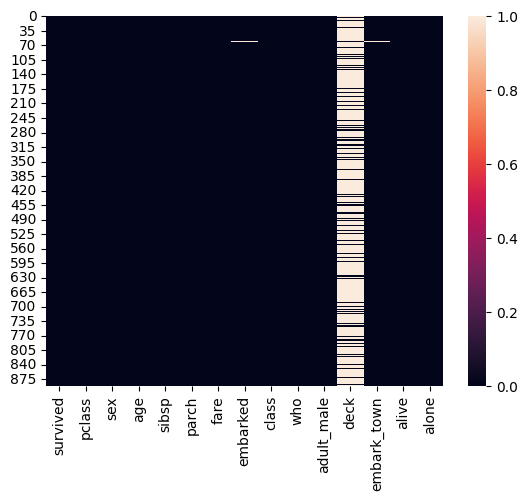

In [13]:
# 2nd step is to find missing values

# there are multiple ways to find missing values 
# we can use isnull() function to find missing values
# df.isnull().sum()
# if we want to see missing values in percentage
# (df.isnull().sum() / len(df)) * 100
(df.isnull().sum() / len(df)) * 100

# we can use heatmap to visualize missing values
sns.heatmap(df.isnull())



In [4]:
# 3rd step is to deal with missing values
# we use mean median mode to fill missing values
# for numerical columns we use mean or median
# or we use forward fill or backward fill method

# Load of missing values in deck column if missing values are more than 40% we can drop the column
df.drop('deck', axis=1, inplace=True)
df.head()






,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [5]:
# Now we fill missing values in age / embark_town / embarked column with median / mode
df['age'].fillna(df['age'].median(), inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


# we also use forward fill and backward fill method to fill missing values
# df['age'].fillna(method='ffill', inplace=True)
# df['age'].fillna(method='bfill', inplace=True)

df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Now we fill or impute values through Sk Learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# First we load the dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# SimpleImputer 

# Agar aapko fast aur simple solution chahiye → SimpleImputer
# Agar aapko accuracy aur feature relationships important hain → IterativeImputer

# 1st step now we load the sklearn library to fill missing values
# 2nd step we impute age column missing values with mean or median using SimpleImputer

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])


df.isnull().sum()




survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# Multiple Imputer

# Agar aapko fast aur simple solution chahiye → SimpleImputer
# Agar aapko accuracy aur feature relationships important hain → IterativeImputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer()
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])    
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
# using KNN Imputer to fill missing values
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64